# Entity Resolution Bakeoff

**Five approaches, one mention set, one gold clustering, one metric.**

[Notebook 01](01_gliner25_knowledge_graphs.ipynb) builds `kgx.EntityResolver` — normalise, block, score,
cluster, canonicalise — and reports B-cubed F1 0.946 on this corpus. What it never does is check whether a
library someone else maintains would do better. This notebook does.

Everything below runs on the **same 214 mentions**, extracted once by `kgx.GlinerExtractor` from the ten
`BUSINESS_NEWS` documents, and is scored against the **same 13 gold entities** in
`kgx.data.documents.ALIAS_GROUPS` with the **same** `kgx.bcubed`. No approach gets its own preprocessing.

| | what it is | training | deterministic |
|---|---|---|---|
| **`kgx.EntityResolver`** | the repo's hand-rolled pipeline | none | yes |
| **Splink 4** | Fellegi–Sunter over DuckDB, EM-trained m/u | unsupervised EM | yes |
| **dedupe 3** | logistic regression + learned blocking predicates | supervised, active | **seeded only** |
| **cross-encoder** | `sentence-transformers` reranker over candidate pairs | pretrained | yes |
| **LLM adjudication** | Claude Haiku on the pairs the scorer cannot call | none | cached |

### The short version

**The hand-rolled pipeline is not the best system here, and it loses on candidate generation rather than on
scoring.** `kgx.EntityResolver` scores B-cubed F1 0.946 at precision 1.000. Two approaches reach 1.000:
a Splink configuration whose blocking rules ignore the extractor's type field (and whose type penalty is
soft enough to let the resulting pairs through), and Claude Haiku adjudicating a deliberately widened
candidate set for six cents a pass. Both fix the same thing — 41 true pairs, 12% of the total, that a
type-blocked candidate generator can never propose.

Along the way, four results that a summary table would hide. Splink's expectation–maximisation contributes
nothing on a single-column table and its `match_probability` is not calibrated — the best threshold is 0.1,
not 0.9. dedupe discovers exactly the right blocking predicate, and how often it discovers it is decided by
how many labels you buy: five seeds span F1 0.922 to 0.968 at a 40/60 label budget and 0.438 to 0.945 at
25/25. The 0.78–0.90 review band that `Resolution.review_band()` exists to
produce holds nothing a gold label disagrees about, so both a cross-encoder and an LLM score perfectly on
its labelled pairs and move B-cubed by zero. And a cross-encoder scores `HLCN` against `Halcyon` at the very
bottom of its range — these are string-similarity models, and an acronym is the case they get most
confidently wrong.

In [1]:
import os, sys, time, json, logging, warnings, itertools, re
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("splink").setLevel(logging.ERROR)
logging.getLogger("dedupe").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 48)

import kgx
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS
from kgx.extract import Mention

print(f"corpus   {len(DOCUMENTS)} documents")
print(f"gold     {len(ALIAS_GROUPS)} alias groups")
print(f"kgx      EntityResolver, bcubed, GlinerExtractor")

corpus   10 documents
gold     13 alias groups
kgx      EntityResolver, bcubed, GlinerExtractor


## 0. One mention set

Entity resolution takes mentions and returns clusters. Every number below therefore depends on the mention
set, so it is produced once and cached to disk — re-running the notebook must not silently re-extract with
a different model version and quietly move every result.

The gold labels come from `ALIAS_GROUPS`: 13 entities, each listed with its surface forms. A mention is
labelled if its stripped surface string appears in exactly one group. That covers 77 of the 214 mentions;
the other 137 are unlabelled and B-cubed ignores them, which matters later — a clustering can look perfect
on the labelled subset while quietly fusing everything else. §3 audits that.

In [2]:
CACHE = ROOT / "output" / "mentions_cache.csv"

def build_mention_cache(path: Path) -> pd.DataFrame:
    """One GLiNER pass over the corpus, plus gold labels from ALIAS_GROUPS."""
    ex = kgx.GlinerExtractor()
    mentions = [m for g in ex.extract_batch(DOCUMENTS, kgx.BUSINESS_NEWS) for m in g.mentions]
    frame = pd.DataFrame([m.as_record() for m in mentions])
    label = {}
    for canon, aliases in ALIAS_GROUPS.items():
        surfaces = {a.strip() for a in aliases}
        for m in mentions:
            if m.text.strip() in surfaces:
                label[m.mention_id] = canon
    frame["gold"] = frame["mention_id"].map(label)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame

t = time.perf_counter()
if CACHE.exists():
    df = pd.read_csv(CACHE)
    source = f"cache {CACHE.relative_to(ROOT)}"
else:
    df = build_mention_cache(CACHE)
    source = "fresh GLiNER extraction"
df["text"] = df.text.str.strip()
df["context"] = df.context.fillna("")
print(f"{len(df)} mentions from {source} in {time.perf_counter() - t:.1f}s")

MENTIONS = [Mention(mention_id=r.mention_id, doc_id=r.doc_id, type=r.type, text=r.text,
                    start=int(r.start), end=int(r.end), confidence=float(r.confidence),
                    context=r.context)
            for r in df.itertuples()]
GOLD = dict(df.dropna(subset=["gold"])[["mention_id", "gold"]].values)
TEXT = dict(zip(df.mention_id, df.text))
TYPE = dict(zip(df.mention_id, df.type))
CONTEXT = dict(zip(df.mention_id, df.context))
IDS  = list(df.mention_id)

print(f"{len(GOLD)} gold-labelled mentions over {df.gold.nunique()} entities, "
      f"{len(df) - len(GOLD)} unlabelled")
print(f"{df.type.nunique()} extractor types: {dict(df.type.value_counts())}")

214 mentions from cache output/mentions_cache.csv in 0.0s
77 gold-labelled mentions over 13 entities, 137 unlabelled
12 extractor types: {'company': np.int64(47), 'geography': np.int64(35), 'financial_metric': np.int64(27), 'person': np.int64(20), 'product': np.int64(15), 'business_segment': np.int64(12), 'security': np.int64(11), 'regulator': np.int64(11), 'commodity': np.int64(11), 'sector': np.int64(10), 'business_event': np.int64(9), 'risk_factor': np.int64(6)}


## 1. The metric, and the ceiling above it

**B-cubed**, not pairwise F1. Pairwise scores are dominated by whichever cluster is largest, so one
over-merge of the two most frequent entities can look like a triumph. B-cubed averages precision and recall
per *mention*, which makes a 19-mention cluster worth 19 votes rather than 171 pairs.

The other number that matters is **pair completeness**: the fraction of true within-entity pairs that a
system's candidate generation ever puts in front of its scorer. It is a hard ceiling on recall — a pair that
is never scored can never be merged, and no threshold tuning gets it back. Reporting only end-to-end F1
means tuning the scorer when the blocker is the problem.

In [3]:
TRUE_PAIRS = {tuple(sorted((a, b)))
              for a, b in itertools.combinations(GOLD, 2) if GOLD[a] == GOLD[b]}
ALL_PAIRS  = {tuple(sorted((a, b))) for a, b in itertools.combinations(IDS, 2)}

print(f"{len(ALL_PAIRS):6} pairs in the full cartesian product of 214 mentions")
print(f"{len(TRUE_PAIRS):6} true within-entity pairs among the {len(GOLD)} labelled mentions")

def pair_completeness(candidates) -> float:
    """Fraction of true pairs that survived candidate generation. Ceiling on recall."""
    got = {tuple(sorted(p)) for p in candidates}
    return len(TRUE_PAIRS & got) / len(TRUE_PAIRS)

BOARD = []

def record(approach, mention_to_cluster, *, blocking=None, seconds=None, loc=None,
           calibrated=None, note="", quiet=False):
    """Score one clustering and append it to the scoreboard assembled in §7."""
    b = kgx.bcubed(mention_to_cluster, GOLD)
    row = {"approach": approach, "B3 P": b["precision"], "B3 R": b["recall"], "B3 F1": b["f1"],
           "clusters": len(set(mention_to_cluster.values())), "blocking recall": blocking,
           "seconds": None if seconds is None else round(seconds, 2), "config lines": loc,
           "calibrated": calibrated, "note": note}
    BOARD.append(row)
    if not quiet:
        print(f"  {approach:<44} clusters={row['clusters']:4}  "
              f"B3 P={b['precision']:.3f} R={b['recall']:.3f} F1={b['f1']:.3f}")
    return b

def show(label, mention_to_cluster, extra=""):
    """Score without touching the scoreboard -- for threshold sweeps."""
    b = kgx.bcubed(mention_to_cluster, GOLD)
    print(f"  {label:<44} clusters={len(set(mention_to_cluster.values())):4}  "
          f"B3 P={b['precision']:.3f} R={b['recall']:.3f} F1={b['f1']:.3f}  {extra}")
    return b

 22791 pairs in the full cartesian product of 214 mentions
   339 true within-entity pairs among the 77 labelled mentions


### The trap that decides this notebook

GLiNER assigns each mention a type, and every sane blocker uses type as a partition key — comparing a
`person` to a `commodity` is wasted work, and *Apple* the company embeds almost identically to *Apple* the
product. `kgx.EntityResolver.block` does exactly that, and so does the idiomatic Splink configuration.

But the extractor is not consistent about type. A ticker is sometimes `security` and sometimes `company`;
the same surface string gets both labels in different documents. Every such pair is invisible to a
type-blocked system, permanently.

In [4]:
from collections import Counter

cross = [p for p in TRUE_PAIRS if TYPE[p[0]] != TYPE[p[1]]]
print(f"{len(cross)}/{len(TRUE_PAIRS)} true pairs ({len(cross)/len(TRUE_PAIRS):.1%}) "
      f"span two different extractor types\n")
counts = Counter(tuple(sorted((f"{TEXT[a]} [{TYPE[a]}]", f"{TEXT[b]} [{TYPE[b]}]"))) for a, b in cross)
display(pd.DataFrame([{"pair": f"{x}  <->  {y}", "n": n} for (x, y), n in counts.most_common()])
        .set_index("pair"))
print(f"pair-completeness ceiling for ANY type-blocked candidate generator: "
      f"{1 - len(cross)/len(TRUE_PAIRS):.3f}")

41/339 true pairs (12.1%) span two different extractor types



,n
pair,
HLCN [security] <-> Halcyon [company],18
HLCN [security] <-> Halcyon Semiconductor [company],9
HLCN [security] <-> Halcyon Semiconductor Corporation [company],6
Vantage Energy Partners [company] <-> Vantage Energy Partners [security],4
Torrent Microsystems [company] <-> Torrent Microsystems [security],4


pair-completeness ceiling for ANY type-blocked candidate generator: 0.879


## 2. The baseline, broken into stages

`kgx.EntityResolver` is five stages: normalise, block, score, cluster, canonicalise. Blocking is
type-constrained and unions five deterministic keys (head token, tail token, surname, initials, exact
normalised key, plus any alias mined from the corpus) with an embedding kNN over
`all-MiniLM-L6-v2`. Scoring is a weighted sum of fuzzy string distance, embedding cosine and local-context
agreement, short-circuited by three deterministic rules. Clustering is connected components at 0.90.

Run it first, then take it apart.

In [5]:
resolver = kgx.EntityResolver(threshold=0.90).learn_aliases(d["text"] for d in DOCUMENTS)
resolver.encoder                 # force the MiniLM load out of the timed section
resolver.resolve(MENTIONS[:4])   # and the lazy networkx / rapidfuzz imports too

t = time.perf_counter()
res = resolver.resolve(MENTIONS)
t_baseline = time.perf_counter() - t

blk = resolver.blocking_report(MENTIONS, GOLD)
scored_pairs = {tuple(sorted((p.a, p.b))) for p in res.pairs}

print(f"resolve({len(MENTIONS)} mentions) = {t_baseline*1000:.0f} ms")
print(json.dumps(res.stats, indent=1))
record("kgx.EntityResolver (t=0.90)", res.mention_to_canon,
       blocking=pair_completeness(scored_pairs), seconds=t_baseline, loc=2,
       calibrated="n/a", note="repo baseline")

resolve(214 mentions) = 148 ms
{
 "mentions": 214,
 "canonical_entities": 109,
 "reduction": 0.491,
 "candidate_pairs": 1462,
 "all_pairs": 22791,
 "reduction_ratio": 0.9359,
 "accepted_pairs": 363,
 "embeddings": true
}
  kgx.EntityResolver (t=0.90)                  clusters= 109  B3 P=1.000 R=0.897 F1=0.946


{'precision': 1.0, 'recall': 0.8972, 'f1': 0.9458, 'n': 77}

`candidate_pairs` counts what survived blocking **and** the same-type filter inside `resolve`: 1462 of
22791 possible pairs, a 93.6% reduction. The pair completeness printed above is measured over exactly that
set, so it is the real ceiling and not a flattering one taken before the type filter.

### Where the recall comes from

Four ablations of the same pipeline. Each removes one source of candidate pairs, so the F1 column shows
what that source is actually worth rather than what it sounds like it should be worth.

In [6]:
def ablate(label, *, use_embeddings, learn):
    er = kgx.EntityResolver(threshold=0.90, use_embeddings=use_embeddings)
    if learn:
        er.learn_aliases(d["text"] for d in DOCUMENTS)
    if use_embeddings:
        er.encoder                                  # warm the model outside the timer
    t0 = time.perf_counter()
    r = er.resolve(MENTIONS)
    dt = time.perf_counter() - t0
    b = kgx.bcubed(r.mention_to_canon, GOLD)
    return {"stage": label,
            "B3 P": b["precision"], "B3 R": b["recall"], "B3 F1": b["f1"],
            "clusters": len(r.entities), "cand pairs": len(r.pairs),
            "blocking recall": round(pair_completeness({tuple(sorted((p.a, p.b))) for p in r.pairs}), 3),
            "ms": round(dt * 1000)}

stages = pd.DataFrame([
    ablate("1. string keys only",          use_embeddings=False, learn=False),
    ablate("2. + aliases mined from text", use_embeddings=False, learn=True),
    ablate("3. + embedding kNN blocking",  use_embeddings=True,  learn=False),
    ablate("4. both (the default)",        use_embeddings=True,  learn=True),
]).set_index("stage")
display(stages)

mined = kgx.resolve.detect_aliases(d["text"] for d in DOCUMENTS)
print("aliases mined from the corpus text:", sorted(mined))

,B3 P,B3 R,B3 F1,clusters,cand pairs,blocking recall,ms
stage,,,,,,,
1. string keys only,1.0,0.7378,0.8491,113,429,0.740,4
2. + aliases mined from text,1.0,0.8035,0.8910,112,474,0.873,3
3. + embedding kNN blocking,1.0,0.8972,0.9458,109,1440,0.814,106
4. both (the default),1.0,0.8972,0.9458,109,1462,0.879,111


aliases mined from the corpus text: [('halcyon semiconductor', 'hlcn'), ('northwind logistics', 'nwl')]


Two things in that table are worth stopping on.

The embedding kNN is where the F1 comes from — 0.891 to 0.946 — and it is forty times slower than the
string-only configuration. That is essentially the whole runtime of this pipeline, spent on one stage.

And the alias miner *raises blocking recall while leaving F1 unchanged*. Row 3 has lower pair completeness
than row 4 and identical B-cubed. Candidate pairs only pay off when the pair is not already connected by
some other edge; `NWL`/`Northwind Logistics` was already in the same component transitively, so proposing it
again buys nothing. Blocking recall is a ceiling, not a score.

### What the accepted merges are actually made of

In [7]:
accepted = res.pairs_frame().query("score >= 0.90")
print(f"{len(accepted)} pairs accepted at 0.90, by the evidence that got them there:\n")
display(accepted.reason.value_counts().rename("pairs").to_frame())

print("\ncandidate pairs by blocker:")
display(res.pairs_frame().block.value_counts().rename("pairs").to_frame())

363 pairs accepted at 0.90, by the evidence that got them there:



,pairs
reason,
exact normalised match,304
alias declared in corpus text,45
"org name is a token prefix, context agrees",12
acronym expansion,2



candidate pairs by blocker:


,pairs
block,
ann,988
head,358
alias,48
tail,36
init,32


84% of the merges are `exact normalised match` — the same string twice. The learned parts of the pipeline
are deciding a few dozen edges, and the embedding tier that costs forty times the string-only runtime is
mostly there to *propose* pairs that the exact-match rule then settles: `ann` supplies two thirds of the
candidates and almost none of the reasons.

### The 10.3% that is missing

Where does the remaining recall go? Two places, and they are not the same size.

In [8]:
missing = TRUE_PAIRS - scored_pairs
below   = [p for p in res.pairs if tuple(sorted((p.a, p.b))) in TRUE_PAIRS and p.score < 0.90]

print(f"true pairs never scored at all (blocking) : {len(missing):3}")
print(f"true pairs scored but below threshold     : {len(below):3}")
print(f"   their scores: {dict(Counter(round(p.score, 2) for p in below).most_common())}")

band = res.review_band(low=0.78)
labelled = [p for p in band if p.a in GOLD and p.b in GOLD]
n_true = sum(1 for p in labelled if GOLD[p.a] == GOLD[p.b])
print(f"\nreview band 0.78 <= score < 0.90: {len(band)} pairs, "
      f"{len(labelled)} with gold labels on both sides")
print(f"   of those {len(labelled)}: {n_true} true, {len(labelled) - n_true} false")

same_component = sum(1 for p in labelled
                     if res.mention_to_canon[p.a] == res.mention_to_canon[p.b])
print(f"   already in the same cluster after transitive closure: {same_component}/{len(labelled)}")
print(f"\nall {len(missing)} never-scored pairs are cross-type: "
      f"{all(TYPE[a] != TYPE[b] for a, b in missing)}")

true pairs never scored at all (blocking) :  41
true pairs scored but below threshold     :  40
   their scores: {0.88: 34, 0.63: 3, 0.22: 1, 0.15: 1, 0.25: 1}

review band 0.78 <= score < 0.90: 39 pairs, 34 with gold labels on both sides
   of those 34: 34 true, 0 false
   already in the same cluster after transitive closure: 34/34

all 41 never-scored pairs are cross-type: True


This is the finding the rest of the notebook is organised around.

The review band — the queue a human or an LLM is supposed to work through — contains **no disagreement gold
can see**. Every labelled pair in it is a true match, every one of them is *already* merged transitively by
some other edge, and there is not a single labelled false pair to reject. The other five pairs carry no gold
label at all, so an adjudicator pointed at this band cannot improve the score whatever it decides about
them.

The entire remaining gap is 41 pairs that were never scored, because the two mentions carry different
extractor types. §5 and §6 are the two ways to attack that; §3 and §4 are what the libraries do with the
same problem.

## 3. Splink 4

[Splink](https://moj-analytical-services.github.io/splink/) is the Ministry of Justice's probabilistic
linkage library: Fellegi–Sunter, m/u parameters estimated by expectation–maximisation, executed as SQL
against DuckDB. `uv add splink` pulls 19 MB of pure wheels — duckdb, igraph, altair, sqlglot — and nothing
that touches torch, transformers, numpy or pandas.

The data model is a flat table. One row per mention, one column per comparable attribute. This corpus has
**one informative column** (the name) and one weak one (the extractor type), which is not what Fellegi–Sunter
was designed for. Four configurations, each fixing one thing the previous one got wrong.

In [9]:
from splink import DuckDBAPI, Linker, SettingsCreator, block_on
import splink.comparison_library as cl
import splink.comparison_level_library as cll

def clean_name(s: pd.Series) -> pd.Series:
    """Casefold, strip punctuation, drop legal suffixes. Shared by Splink and dedupe."""
    return (s.str.casefold()
             .str.replace(r"[^\w\s]", " ", regex=True)
             .str.replace(r"\b(inc|incorporated|corp|corporation|llc|ltd|plc|co|company|the)\b",
                          " ", regex=True)
             .str.replace(r"\s+", " ", regex=True)
             .str.strip())

REC = pd.DataFrame({"unique_id": df.mention_id, "name": df.text, "type": df.type,
                    "doc_id": df.doc_id, "context": df.context})
REC["name_clean"] = clean_name(REC.name)
REC["first_tok"]  = REC.name_clean.str.split().str[0].fillna("")
display(REC.head(6))

,unique_id,name,type,doc_id,context,name_clean,first_tok
0,d01:e1,SEATTLE,geography,d01,SEATTLE — Northwind Logistics Inc. (NASDAQ: ...,seattle,seattle
1,d01:e2,Northwind Logistics Inc.,company,d01,SEATTLE — Northwind Logistics Inc. (NASDAQ: ...,northwind logistics,northwind
2,d01:e3,Cascade Freight Systems,company,d01,(NASDAQ: NWL) today announced that it has en...,cascade freight systems,cascade
3,d01:e4,cash,security,d01,ntered into a definitive agreement to acquir...,cash,cash
4,d01:e5,stock,security,d01,to a definitive agreement to acquire Cascade...,stock,stock
5,d01:e6,agreement,business_event,d01,cquire Cascade Freight Systems for $1.4 bill...,agreement,agreement


In [10]:
def splink_run(name, comparisons, blocking, *, em_rules=None, sweep=(0.1, 0.5, 0.9),
               p_two_random=None):
    """Build, optionally train, predict, and sweep the clustering threshold.

    Returns (best_threshold, bcubed, mention_to_cluster, timings, pair_completeness).
    """
    t0 = time.perf_counter()
    kw = {} if p_two_random is None else {"probability_two_random_records_match": p_two_random}
    settings = SettingsCreator(link_type="dedupe_only", comparisons=comparisons,
                               blocking_rules_to_generate_predictions=blocking, **kw)
    linker = Linker(REC, settings, db_api=DuckDBAPI(), set_up_basic_logging=False)
    if em_rules:
        linker.training.estimate_probability_two_random_records_match(
            [block_on("name_clean")], recall=0.7)
        linker.training.estimate_u_using_random_sampling(max_pairs=1e6, seed=1)
        for rule in em_rules:
            linker.training.estimate_parameters_using_expectation_maximisation(rule)
    t_fit = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds = linker.inference.predict(threshold_match_probability=0.0)   # everything blocking produced
    pdf = preds.as_pandas_dataframe()
    t_pred = time.perf_counter() - t0
    pc = pair_completeness(zip(pdf.unique_id_l, pdf.unique_id_r))

    print(f"  {name}:  fit={t_fit:.2f}s predict={t_pred:.2f}s  "
          f"scored_pairs={len(pdf)}  blocking recall={pc:.3f}")
    best = None
    for th in sweep:
        t0 = time.perf_counter()
        cdf = linker.clustering.cluster_pairwise_predictions_at_threshold(
            preds, threshold_match_probability=th).as_pandas_dataframe()
        t_cl = time.perf_counter() - t0
        m2c = dict(zip(cdf.unique_id, cdf.cluster_id.astype(str)))
        b = show(f"match_probability >= {th}", m2c, extra=f"cluster={t_cl:.2f}s")
        if best is None or b["f1"] > best[1]["f1"]:
            best = (th, b, m2c, t_fit + t_pred + t_cl, pc, linker)
    return best

### Config A — the textbook shape

`NameComparison` on the cleaned name, `ExactMatch` on the type, block on type and first token, then the
three training calls every Splink tutorial makes.

In [11]:
A = splink_run("A: name + type, EM-trained",
               comparisons=[cl.NameComparison("name_clean"), cl.ExactMatch("type")],
               blocking=[block_on("type"), block_on("first_tok")],
               em_rules=[block_on("type")],
               sweep=(0.05, 0.1, 0.5, 0.9, 0.99))

  A: name + type, EM-trained:  fit=0.30s predict=0.03s  scored_pairs=2706  blocking recall=0.903
  match_probability >= 0.05                    clusters=  91  B3 P=1.000 R=0.880 F1=0.936  cluster=0.02s
  match_probability >= 0.1                     clusters=  97  B3 P=1.000 R=0.880 F1=0.936  cluster=0.02s
  match_probability >= 0.5                     clusters=  97  B3 P=1.000 R=0.880 F1=0.936  cluster=0.02s
  match_probability >= 0.9                     clusters= 204  B3 P=1.000 R=0.203 F1=0.338  cluster=0.01s
  match_probability >= 0.99                    clusters= 214  B3 P=1.000 R=0.169 F1=0.289  cluster=0.01s


### EM has nothing to estimate

`estimate_parameters_using_expectation_maximisation(block_on("type"))` holds `type` fixed and estimates
`name_clean` from the pairs inside each type block. With two columns, fixing one leaves exactly one free —
and the fixed column's own m values are then never estimated by anything. Splink says so at predict time,
in a warning that is easy to scroll past.

In [12]:
import io
buf = io.StringIO()
handler = logging.StreamHandler(buf)
log = logging.getLogger("splink")
log.setLevel(logging.WARNING); log.addHandler(handler)
A[5].inference.predict(threshold_match_probability=0.0).as_pandas_dataframe()
log.removeHandler(handler); log.setLevel(logging.ERROR)
print(buf.getvalue().strip() or "(no warning)")

trained = A[5].misc.save_model_to_json()
for comp in trained["comparisons"]:
    ms = [lvl.get("m_probability") for lvl in comp["comparison_levels"]]
    print(f"\n{comp['output_column_name']:>12}  m per level: {ms}")

-- WARNING --
You have called predict(), but there are some parameter estimates which have neither been estimated or specified in your settings dictionary.  To produce predictions the following untrained trained parameters will use default values.
Comparison: 'type':
    m values not fully trained

  name_clean  m per level: [None, 0.7060599073843272, 0.011009343802986085, 0.09850469538713917, 0.17628296800263457, 0.00814308542291293]

        type  m per level: [None, None, None]


The `type` comparison comes out of training with **no m probabilities at all** — Splink falls back to
defaults for it. Fellegi–Sunter assumes several conditionally independent fields; with one informative
column there is nothing to condition on, and EM is doing no work you could not do by hand.

So do it by hand. Config B specifies m/u directly and makes zero training calls.

In [13]:
NAME_LEVELS = [
    cll.NullLevel("name_clean"),
    cll.ExactMatchLevel("name_clean").configure(m_probability=0.55, u_probability=0.001),
    cll.JaroWinklerLevel("name_clean", 0.92).configure(m_probability=0.20, u_probability=0.002),
    cll.JaroWinklerLevel("name_clean", 0.80).configure(m_probability=0.15, u_probability=0.01),
    cll.JaroWinklerLevel("name_clean", 0.70).configure(m_probability=0.07, u_probability=0.05),
    cll.ElseLevel().configure(m_probability=0.03, u_probability=0.937),
]
TYPE_HARD = cl.CustomComparison(
    output_column_name="type", comparison_description="type",
    comparison_levels=[
        cll.NullLevel("type"),
        cll.ExactMatchLevel("type").configure(m_probability=0.99, u_probability=0.15),
        cll.ElseLevel().configure(m_probability=0.01, u_probability=0.85),
    ])

B = splink_run("B: hand-set m/u, zero training",
               comparisons=[cl.CustomComparison(output_column_name="name_clean",
                                                comparison_description="name (hand-tuned m/u)",
                                                comparison_levels=NAME_LEVELS),
                            TYPE_HARD],
               blocking=[block_on("type")],
               sweep=(0.1, 0.5, 0.9, 0.99), p_two_random=0.02)

  B: hand-set m/u, zero training:  fit=0.02s predict=0.02s  scored_pairs=2649  blocking recall=0.879
  match_probability >= 0.1                     clusters=  97  B3 P=1.000 R=0.880 F1=0.936  cluster=0.02s
  match_probability >= 0.5                     clusters= 101  B3 P=1.000 R=0.814 F1=0.898  cluster=0.01s


  match_probability >= 0.9                     clusters= 112  B3 P=1.000 R=0.717 F1=0.835  cluster=0.01s
  match_probability >= 0.99                    clusters= 214  B3 P=1.000 R=0.169 F1=0.289  cluster=0.01s


Hand-set m/u ties the EM-trained model. Twenty-five iterations of expectation–maximisation bought nothing.

### The ceiling on string distance

Before adding levels, it is worth knowing what any Jaro-Winkler threshold can reach at all. Every one of the
339 true pairs, scored by JW on the cleaned name.

In [14]:
from rapidfuzz.distance import JaroWinkler

clean = dict(zip(REC.unique_id, REC.name_clean))
rows, unreachable = [], set()
for th in (0.92, 0.88, 0.80, 0.70):
    tp = fp = 0
    for a, b in ALL_PAIRS:
        if a not in GOLD or b not in GOLD:
            continue
        if JaroWinkler.similarity(clean[a], clean[b]) >= th:
            if GOLD[a] == GOLD[b]:
                tp += 1
            else:
                fp += 1
    rows.append({"JW level": f">= {th}", "true pairs caught": tp,
                 "recall": round(tp / len(TRUE_PAIRS), 3), "false pairs caught": fp})
display(pd.DataFrame(rows).set_index("JW level"))

for a, b in TRUE_PAIRS:
    s = JaroWinkler.similarity(clean[a], clean[b])
    if s < 0.70:
        unreachable.add((tuple(sorted((TEXT[a], TEXT[b]))), round(s, 3)))
print("true pairs no Jaro-Winkler level can reach:")
for (x, y), s in sorted(unreachable):
    print(f"   {x!r:38} <-> {y!r:38} JW={s}")

print(f"\ncomparison levels in splink.comparison_library: "
      f"{len([n for n in dir(cl) if n[0].isupper()])}")
print("levels that model an acronym or an abbreviation:",
      [n for n in dir(cl) if "acr" in n.lower() or "abbrev" in n.lower()] or "none")

,true pairs caught,recall,false pairs caught
JW level,,,
>= 0.92,207,0.611,0
>= 0.88,222,0.655,0
>= 0.8,256,0.755,0
>= 0.7,334,0.985,0


true pairs no Jaro-Winkler level can reach:
   'NWL'                                  <-> 'Northwind'                            JW=0.481
   'SEC'                                  <-> 'Securities and Exchange Commission'   JW=0.696

comparison levels in splink.comparison_library: 19
levels that model an acronym or an abbreviation: none


Splink ships nineteen comparison templates — names, postcodes, dates, emails, distances — and not one of
them models an abbreviation. `NWL` against `Northwind` is Jaro-Winkler 0.481, well below the *else* level, and
lowering the threshold far enough to catch it would drag in everything.

The escape hatch is `cll.CustomLevel`, which takes raw SQL in the backend's dialect. Ten lines of DuckDB
that test whether the short side's characters appear in order in the long side:

In [15]:
ACRONYM_SQL = """
(   length("name_clean_r") between 2 and 5
    and position(' ' in "name_clean_r") = 0
    and regexp_full_match("name_clean_l",
          '.*' || array_to_string(regexp_split_to_array("name_clean_r", ''), '.*') || '.*')
) or (
    length("name_clean_l") between 2 and 5
    and position(' ' in "name_clean_l") = 0
    and regexp_full_match("name_clean_r",
          '.*' || array_to_string(regexp_split_to_array("name_clean_l", ''), '.*') || '.*')
)
"""
ACRONYM_LEVELS = NAME_LEVELS[:4] + [
    cll.CustomLevel(ACRONYM_SQL, "acronym subsequence").configure(
        m_probability=0.10, u_probability=0.004)
] + NAME_LEVELS[4:]

NAME_ACR = cl.CustomComparison(output_column_name="name_clean",
                               comparison_description="name + acronym",
                               comparison_levels=ACRONYM_LEVELS)

C = splink_run("C: B + acronym level", comparisons=[NAME_ACR, TYPE_HARD],
               blocking=[block_on("type")], sweep=(0.1, 0.5, 0.9, 0.99), p_two_random=0.02)

  C: B + acronym level:  fit=0.02s predict=0.03s  scored_pairs=2649  blocking recall=0.879
  match_probability >= 0.1                     clusters=  94  B3 P=1.000 R=0.897 F1=0.946  cluster=0.02s


  match_probability >= 0.5                     clusters=  97  B3 P=1.000 R=0.897 F1=0.946  cluster=0.01s
  match_probability >= 0.9                     clusters= 112  B3 P=1.000 R=0.717 F1=0.835  cluster=0.01s
  match_probability >= 0.99                    clusters= 214  B3 P=1.000 R=0.169 F1=0.289  cluster=0.01s


Ten lines of SQL, plus 0.010 F1. Config C now ties the hand-rolled pipeline exactly.

### Config D — fix the blocker instead

C still blocks on type, so it inherits the 0.879 ceiling from §1. Add two type-agnostic blocking rules and
soften the type penalty from a 99:1 likelihood ratio to 4:1, so a `security` can still be compared to a
`company` and merely pays for the mismatch.

In [16]:
TYPE_SOFT = cl.CustomComparison(
    output_column_name="type", comparison_description="type (soft)",
    comparison_levels=[
        cll.NullLevel("type"),
        cll.ExactMatchLevel("type").configure(m_probability=0.80, u_probability=0.15),
        cll.ElseLevel().configure(m_probability=0.20, u_probability=0.85),
    ])

D = splink_run("D: C + cross-type blocking",
               comparisons=[NAME_ACR, TYPE_SOFT],
               blocking=[block_on("type"), block_on("first_tok"),
                         block_on("substr(name_clean, 1, 1)")],
               sweep=(0.1, 0.3, 0.5, 0.9, 0.99), p_two_random=0.02)

for tag, best in (("A: EM-trained", A), ("B: hand m/u", B), ("C: + acronym SQL", C),
                  ("D: + cross-type blocking", D)):
    record(f"Splink 4 — {tag}", best[2], blocking=best[4], seconds=best[3],
           loc={"A: EM-trained": 8, "B: hand m/u": 22, "C: + acronym SQL": 33,
                "D: + cross-type blocking": 41}[tag],
           calibrated="no", note=f"best at p>={best[0]}", quiet=True)

display(pd.DataFrame(BOARD[-4:]).set_index("approach")[
    ["B3 P", "B3 R", "B3 F1", "clusters", "blocking recall", "seconds"]])

  D: C + cross-type blocking:  fit=0.02s predict=0.03s  scored_pairs=3769  blocking recall=1.000


  match_probability >= 0.1                     clusters=  86  B3 P=1.000 R=1.000 F1=1.000  cluster=0.02s


  match_probability >= 0.3                     clusters=  93  B3 P=1.000 R=0.939 F1=0.968  cluster=0.01s
  match_probability >= 0.5                     clusters=  94  B3 P=1.000 R=0.939 F1=0.968  cluster=0.01s
  match_probability >= 0.9                     clusters= 112  B3 P=1.000 R=0.717 F1=0.835  cluster=0.01s
  match_probability >= 0.99                    clusters= 214  B3 P=1.000 R=0.169 F1=0.289  cluster=0.01s


,B3 P,B3 R,B3 F1,clusters,blocking recall,seconds
approach,,,,,,
Splink 4 — A: EM-trained,1.0,0.8799,0.9361,91,0.902655,0.35
Splink 4 — B: hand m/u,1.0,0.8799,0.9361,97,0.879056,0.06
Splink 4 — C: + acronym SQL,1.0,0.8972,0.9458,94,0.879056,0.07
Splink 4 — D: + cross-type blocking,1.0,1.0000,1.0000,86,1.000000,0.07


**Config D reaches B-cubed F1 1.000 — precision 1.000, recall 1.000 — and beats this repo's own pipeline.**
Blocking recall goes 0.879 to 1.000, and build, predict and cluster together take under a tenth of a second.

But D changed two things at once — three blocking rules where C had one, and the type penalty softened from
99:1 to 4:1 — and the tempting reading is that only the blocker mattered. Take each half away.

In [17]:
for tag, comps, blocks in (
    ("D minus the soft type penalty", [NAME_ACR, TYPE_HARD],
     [block_on("type"), block_on("first_tok"), block_on("substr(name_clean, 1, 1)")]),
    ("D minus the wider blocker",     [NAME_ACR, TYPE_SOFT], [block_on("type")]),
):
    splink_run(tag, comparisons=comps, blocking=blocks, sweep=(0.1, 0.5), p_two_random=0.02)

  D minus the soft type penalty:  fit=0.02s predict=0.03s  scored_pairs=3769  blocking recall=1.000
  match_probability >= 0.1                     clusters=  91  B3 P=1.000 R=0.939 F1=0.968  cluster=0.02s
  match_probability >= 0.5                     clusters=  97  B3 P=1.000 R=0.897 F1=0.946  cluster=0.02s


  D minus the wider blocker:  fit=0.02s predict=0.03s  scored_pairs=2649  blocking recall=0.879


  match_probability >= 0.1                     clusters=  94  B3 P=1.000 R=0.897 F1=0.946  cluster=0.02s
  match_probability >= 0.5                     clusters=  97  B3 P=1.000 R=0.897 F1=0.946  cluster=0.02s


Neither half gets there alone. Put the 99:1 penalty back and keep the wider blocker: every true pair is now
inside some candidate block, blocking recall 1.000, but B-cubed recall only reaches 0.939 and F1 tops out at
0.968, because a pair that crosses a type boundary still has to outrun that penalty. Keep the soft penalty
and restore the type-only blocker: blocking recall falls back to 0.879 and the score sits at C's 0.946,
because the pairs the softening was written for are never proposed at all. The wider blocker raises the
ceiling; the soft penalty is what lets the newly visible pairs reach it. "Fix candidate generation, not
scoring" is the larger half of the answer here, not the whole of it.

That result comes with three things a benchmark table would hide.

**It is hand-tuned against the evaluation set.** The cross-type blocking rules and the softened type penalty
were chosen *after* looking at the 41 missing pairs in §1. Read 1.000 as "the ceiling is reachable on this
corpus", not as a generalisation claim. The 0.936 → 0.946 → 1.000 progression is the honest part; the last
number is not a held-out score.

**The match probability is not calibrated.** The best threshold is 0.1 for three of the four configurations
and 0.05 for the fourth. At the conventional 0.9 line every one of them collapses.

In [18]:
calib = []
for tag, best in (("A", A), ("B", B), ("C", C), ("D", D)):
    linker, preds = best[5], best[5].inference.predict(threshold_match_probability=0.0)
    row = {"config": tag}
    for th in (0.1, 0.5, 0.9, 0.99):
        cdf = linker.clustering.cluster_pairwise_predictions_at_threshold(
            preds, threshold_match_probability=th).as_pandas_dataframe()
        row[f"F1 @ {th}"] = kgx.bcubed(dict(zip(cdf.unique_id, cdf.cluster_id.astype(str))),
                                       GOLD)["f1"]
    calib.append(row)
display(pd.DataFrame(calib).set_index("config"))

,F1 @ 0.1,F1 @ 0.5,F1 @ 0.9,F1 @ 0.99
config,,,,
A,0.9361,0.9361,0.3381,0.2889
B,0.9361,0.8976,0.8354,0.2889
C,0.9458,0.9458,0.8354,0.2889
D,1.0000,0.9684,0.8354,0.2889


Splink gives a usable *ordering* of pairs on this data, not a probability. The ergonomics that make it
pleasant on thirty-field person records — 0.95 auto-merges, 0.5–0.95 goes to review — are gone, and the
threshold has to be swept against labels like any other hyperparameter.

**B-cubed only scores 77 of 214 mentions.** Config D could be merging the other 137 into mush and the score
would not notice. Audit it.

In [19]:
from collections import defaultdict

inv = defaultdict(list)
for mid, cid in D[2].items():
    inv[cid].append(mid)
audit = sorted(inv.items(), key=lambda kv: -len(kv[1]))[:6]
with pd.option_context("display.max_colwidth", 210, "display.width", 320):
    display(pd.DataFrame([
        {"n": len(mids), "gold-labelled": sum(1 for m in mids if m in GOLD),
         "distinct forms": len({TEXT[m] for m in mids}),
         "surface forms": ", ".join(sorted({TEXT[m] for m in mids}))}
        for _, mids in audit
    ]))

,n,gold-labelled,distinct forms,surface forms
0,19,19,4,"NWL, Northwind, Northwind Logistics, Northwind Logistics Inc."
1,14,14,4,"HLCN, Halcyon, Halcyon Semiconductor, Halcyon Semiconductor Corporation"
2,8,0,8,"Adjusted earnings per share, Adjusted operating margin, adjusted earnings per share, adjusted operating margin, annual run-rate synergies, non-GAAP earnings per share, non-GAAP gross margin, operating margin"
3,8,0,4,"Freight, Freight Brokerage segment, freight, freight brokerage"
4,8,0,2,"Diesel, diesel"
5,7,0,1,revenue


The two largest clusters are exactly right and are exactly the ones the type blocker could not build. The
third fuses eight distinct financial-metric surfaces — GAAP and non-GAAP earnings per share, gross margin,
operating margin, run-rate synergies — into one node that gold never labelled. Defensible if you want one
node per *financial metric concept*, wrong if you want them separate, and invisible to the score either way.
That is the general problem with a 36%-labelled evaluation set, and it applies to every row in §7.

## 4. dedupe 3

[dedupe](https://github.com/dedupeio/dedupe) takes the opposite bet from Splink. Instead of a generative
model with hand- or EM-set parameters, it trains a regularised logistic regression on labelled pairs and
— the part that matters here — **learns its own blocking predicates** by searching a library of them
(`firstTokenPredicate`, `sortedAcronym`, `commonThreeTokens`, …) for a disjunction that covers the labelled
matches within a recall budget.

Two operational notes before any numbers.

`uv add dedupe` alone produces an install that crashes on the first `prepare_training()` call:
`'BTrees.IFBTree.IFBucket' object has no attribute 'byValue'`. uv resolves `btrees==6.5`, which removed
`byValue`; dedupe 3.0.3 has no upper pin. `uv add dedupe "btrees<6"` is the working install and the pin is
load-bearing.

`dedupe.console_label(deduper)` blocks on stdin and would hang a notebook forever. The programmatic
equivalent is `mark_pairs()`, whose own docstring offers it for "adding training data from an existing
source", combined with `uncertain_pairs()` for the active-learning loop. Nothing below reads stdin.

In [20]:
import random
import importlib.metadata as md
import dedupe
import dedupe.variables as dv
from BTrees import IFBTree

print(f"dedupe {md.version('dedupe')} | btrees {md.version('btrees')} | "
      f"IFBucket.byValue present: {hasattr(IFBTree.IFBucket(), 'byValue')}")

DATA = {r.mention_id: {"name": r.text,
                       "name_clean": clean_name(pd.Series([r.text]))[0],
                       "type": r.type,
                       "context": r.context[:400]}
        for r in df.itertuples()}

VARIABLES = [dv.String("name"), dv.Exact("name_clean"), dv.Exact("type"), dv.Text("context")]

def label_from_gold(n_match=40, n_distinct=60, entities=None):
    """Oracle labels: ask gold. entities=None uses all 13 (train-on-test)."""
    ids = [k for k in GOLD if entities is None or GOLD[k] in entities]
    pos, neg = [], []
    for a, b in itertools.combinations(ids, 2):
        (pos if GOLD[a] == GOLD[b] else neg).append((a, b))
    random.shuffle(pos); random.shuffle(neg)
    return {"match":    [(DATA[a], DATA[b]) for a, b in pos[:n_match]],
            "distinct": [(DATA[a], DATA[b]) for a, b in neg[:n_distinct]]}

def label_from_rules(n=120):
    """No gold at all: deterministic rules stand in for the human labeller."""
    pos, neg = [], []
    for a, b in itertools.combinations(list(DATA), 2):
        ra, rb = DATA[a], DATA[b]
        if ra["type"] != rb["type"]:
            neg.append((a, b))
        elif ra["name_clean"] and ra["name_clean"] == rb["name_clean"]:
            pos.append((a, b))
        elif JaroWinkler.similarity(ra["name_clean"], rb["name_clean"]) < 0.55:
            neg.append((a, b))
    random.shuffle(pos); random.shuffle(neg)
    return {"match":    [(DATA[a], DATA[b]) for a, b in pos[:n]],
            "distinct": [(DATA[a], DATA[b]) for a, b in neg[:n]]}

def active_loop(deduper, rounds=40):
    """uncertain_pairs() + mark_pairs() -- console_label() without the console."""
    n_m = n_d = 0
    for _ in range(rounds):
        pair = deduper.uncertain_pairs()
        if not pair:
            break
        ra, rb = pair[0]
        ka = next(k for k, v in DATA.items() if v == ra)
        kb = next(k for k, v in DATA.items() if v == rb)
        same = ka in GOLD and kb in GOLD and GOLD[ka] == GOLD[kb]
        deduper.mark_pairs({"match": [(ra, rb)], "distinct": []} if same
                           else {"match": [], "distinct": [(ra, rb)]})
        n_m += same; n_d += not same
    return n_m, n_d

dedupe 3.0.3 | btrees 5.2 | IFBucket.byValue present: True


In [21]:
def dedupe_run(name, labeller, active_rounds=0, sweep=(0.3, 0.5, 0.7, 0.9), quiet=False, seed=0):
    random.seed(seed); np.random.seed(seed)     # enough without active learning -- see §4.2
    t0 = time.perf_counter()
    deduper = dedupe.Dedupe(VARIABLES, num_cores=0, in_memory=True)  # 214 records: MP is pure overhead
    deduper.prepare_training(DATA, sample_size=3000, blocked_proportion=0.9)
    pairs = labeller()
    deduper.mark_pairs(pairs)
    n_m, n_d = len(pairs["match"]), len(pairs["distinct"])
    if active_rounds:
        am, ad = active_loop(deduper, active_rounds)
        n_m += am; n_d += ad
    deduper.train(recall=0.95, index_predicates=True)
    t_fit = time.perf_counter() - t0

    best = None
    for th in sweep:
        m2c = {mid: f"c{cid}"
               for cid, (ids, _s) in enumerate(deduper.partition(DATA, threshold=th))
               for mid in ids}
        b = kgx.bcubed(m2c, GOLD)
        if not quiet:
            show(f"{name} @ threshold={th}", m2c)
        if best is None or b["f1"] > best[1]["f1"]:
            best = (th, b, m2c, t_fit, [str(p) for p in deduper.predicates])
    return best

print("MODE 1 — oracle labels from all 13 gold entities (train-on-test upper bound)")
d_gold = dedupe_run("gold-labelled", label_from_gold)
print(f"   learned predicates: {d_gold[4]}")

print("\nMODE 2 — deterministic rules only, gold never consulted")
d_rules = dedupe_run("rule-labelled", label_from_rules)
print(f"   learned predicates: {d_rules[4]}")

print("\nMODE 3 — rule seed plus 40 rounds of uncertain_pairs()/mark_pairs()")
d_active = dedupe_run("rule+active", lambda: label_from_rules(30), active_rounds=40)
print(f"   learned predicates: {d_active[4]}")

MODE 1 — oracle labels from all 13 gold entities (train-on-test upper bound)


  gold-labelled @ threshold=0.3                clusters=  81  B3 P=0.956 R=0.939 F1=0.947  
  gold-labelled @ threshold=0.5                clusters=  98  B3 P=1.000 R=0.939 F1=0.968  


  gold-labelled @ threshold=0.7                clusters= 104  B3 P=1.000 R=0.856 F1=0.922  
  gold-labelled @ threshold=0.9                clusters= 214  B3 P=1.000 R=0.169 F1=0.289  
   learned predicates: ['SimplePredicate: (wholeFieldPredicate, type)', 'SimplePredicate: (sortedAcronym, name)']

MODE 2 — deterministic rules only, gold never consulted


  rule-labelled @ threshold=0.3                clusters= 117  B3 P=1.000 R=0.717 F1=0.835  
  rule-labelled @ threshold=0.5                clusters= 117  B3 P=1.000 R=0.717 F1=0.835  
  rule-labelled @ threshold=0.7                clusters= 117  B3 P=1.000 R=0.717 F1=0.835  
  rule-labelled @ threshold=0.9                clusters= 118  B3 P=1.000 R=0.717 F1=0.835  
   learned predicates: ['(TfidfNGramCanopyPredicate: (0.8, name), SimplePredicate: (wholeFieldPredicate, type))']

MODE 3 — rule seed plus 40 rounds of uncertain_pairs()/mark_pairs()


  rule+active @ threshold=0.3                  clusters= 101  B3 P=1.000 R=0.856 F1=0.922  
  rule+active @ threshold=0.5                  clusters= 108  B3 P=1.000 R=0.856 F1=0.922  
  rule+active @ threshold=0.7                  clusters= 119  B3 P=1.000 R=0.759 F1=0.863  
  rule+active @ threshold=0.9                  clusters= 214  B3 P=1.000 R=0.169 F1=0.289  
   learned predicates: ['SimplePredicate: (firstTokenPredicate, name)']


Mode 1 — oracle labels over all thirteen entities — learns `sortedAcronym(name)`, which is dedupe finding
the thing Splink needed ten lines of hand-written DuckDB for, on its own, from labels. Because predicates
are disjunctive, an acronym predicate blocks **across** types, so `HLCN` and `Halcyon` land in the same
block regardless of what the extractor called them. 0.968 is the highest score in this notebook from a model
that was actually trained, and it beats the hand-rolled pipeline.

It is also train-on-test: those labels come straight from the clustering being scored. Neither of the other
two modes found the acronym predicate. Rules-only conjoined a TF-IDF n-gram canopy with
`wholeFieldPredicate(type)` and scored 0.835, well below the baseline and flat across every threshold. The
active-learning run reached 0.922 at threshold 0.3 on `firstTokenPredicate` alone, also below the baseline.
Which predicate you get is the whole result, and you do not choose it — you draw it, with the labels.

### The label sample decides the predicate

`random` and `numpy.random` are seeded on every fit, so the same seed ought to replay exactly. Two questions
in one cell: does it, and how far does the answer move when the seed changes? The seed sweep runs at both
label budgets — the 40/60 that produced the 0.968 board row, and a leaner 25/25 — because the amount of
oracle you can afford is the knob a real deployment actually turns.

In [22]:
rep = [dedupe_run("repeat", lambda: label_from_gold(25, 25), quiet=True, seed=0)
       for _ in range(2)]
print(f"same seed twice: predicates identical={rep[0][4] == rep[1][4]}, "
      f"F1 {rep[0][1]['f1']:.4f} vs {rep[1][1]['f1']:.4f}")

seed_rows = []
for n_m, n_d in ((40, 60), (25, 25)):
    for s in range(5):
        best = dedupe_run(f"seed={s}", lambda: label_from_gold(n_m, n_d), quiet=True, seed=s)
        seed_rows.append({"labels": f"{n_m}/{n_d}", "seed": s, "best threshold": best[0],
                          "B3 P": best[1]["precision"], "B3 R": best[1]["recall"],
                          "B3 F1": best[1]["f1"], "clusters": len(set(best[2].values())),
                          "predicates": ", ".join(p.split(": ")[-1] for p in best[4])[:60]})
seeds = pd.DataFrame(seed_rows).set_index(["labels", "seed"])
display(seeds)
for budget, g in seeds.groupby(level=0, sort=False):
    print(f"{budget} labels, 5 seeds: mean={g['B3 F1'].mean():.3f}  "
          f"min={g['B3 F1'].min():.3f}  max={g['B3 F1'].max():.3f}  "
          f"sd={g['B3 F1'].std():.3f}")

for tag, best, why in (("all-gold labels (train-on-test)", d_gold, "seed-sensitive, see §4.2"),
                       ("rules only, no gold", d_rules, "seed-sensitive, see §4.2"),
                       ("rules + active learning", d_active,
                        "not replayable: uncertain_pairs() is unseeded")):
    record(f"dedupe 3 — {tag}", best[2], blocking=None, seconds=best[3], loc=26,
           calibrated="no", note=f"best at t={best[0]}; {why}", quiet=True)
display(pd.DataFrame(BOARD[-3:]).set_index("approach")[
    ["B3 P", "B3 R", "B3 F1", "clusters", "seconds", "note"]])

same seed twice: predicates identical=True, F1 0.9223 vs 0.9223


best threshold    B3 P    B3 R   B3 F1  clusters                                       predicates
labels seed                                                                                                   
40/60  0                0.5  1.0000  0.9388  0.9684        98  (wholeFieldPredicate, type), (sortedAcronym,...
       1                0.5  1.0000  0.8972  0.9458        99                      (wholeFieldPredicate, type)
       2                0.5  1.0000  0.9388  0.9684        95  (wholeFieldPredicate, type), (sortedAcronym,...
       3                0.5  1.0000  0.9388  0.9684        98  (wholeFieldPredicate, type), (sortedAcronym,...
       4                0.3  1.0000  0.8558  0.9223        94  (firstTokenPredicate, name), (sortedAcronym,...
25/25  0                0.3  1.0000  0.8558  0.9223        97  (firstTokenPredicate, name), (sortedAcronym,...
       1                0.3  1.0000  0.8558  0.9223        99                      (firstTokenPredicate, name)
       2                0.3  0.2901  0.8972  0.4384        12                      (wholeFieldPredicate, type)
       3                0.3  1.0000  0.7630  0.8656       113  (firstTwoTokensPredicate, name), (sortedAcro...
       4                0.3  1.0000  0.8963  0.9453        82  (firstTokenPredicate, name), (sortedAcronym,...

40/60 labels, 5 seeds: mean=0.955  min=0.922  max=0.968  sd=0.021
25/25 labels, 5 seeds: mean=0.819  min=0.438  max=0.945  sd=0.215


,B3 P,B3 R,B3 F1,clusters,seconds,note
approach,,,,,,
dedupe 3 — all-gold labels (train-on-test),1.0,0.9388,0.9684,98,5.61,"best at t=0.5; seed-sensitive, see §4.2"
"dedupe 3 — rules only, no gold",1.0,0.7173,0.8354,117,1.81,"best at t=0.3; seed-sensitive, see §4.2"
dedupe 3 — rules + active learning,1.0,0.8558,0.9223,101,1.06,best at t=0.3; not replayable: uncertain_pai...


Same seed, same answer. Two fits at seed 0 return identical predicates and identical F1 to four decimals,
so nothing about a dedupe fit without active learning is non-deterministic. What moves is the label sample,
and how far it moves is set by how much oracle you are willing to buy.

At 40/60 the answer is stable enough to report: sd 0.021 across five seeds, a 0.922–0.968 range, and three
of the five landing on exactly the `wholeFieldPredicate(type)` + `sortedAcronym(name)` pair mode 1 found.
The 0.968 board row is the top of that range rather than the middle of it; the mean is 0.955. Halve the
budget to 25/25 and the same code spans 0.438 to 0.945, sd 0.215, and the bad seeds are not slightly bad —
seed 2 picked `wholeFieldPredicate(type)` as its only predicate, which fuses each extractor type into a
single cluster: 12 clusters, B-cubed precision 0.29.

The predicate is not the whole story either. Seed 1 at 40/60 learned that same lone
`wholeFieldPredicate(type)` and scored 0.946, because the logistic regression scoring pairs *inside* those
blocks had twice the training data: identical blocking, F1 0.946 against 0.438. And an acronym predicate is
necessary without being sufficient — seed 3 at 25/25 learned `sortedAcronym` and still landed at 0.866.

One mode genuinely will not replay, and it is mode 3. `DisagreementLearner.__init__` builds its generator
with a bare `numpy.random.default_rng()` and `uncertain_pairs()` draws from it, so seeding `random` and
`numpy.random` cannot reach it. The active-learning run above scored 0.922 on `firstTokenPredicate` in this
execution; the previous execution of the identical cell scored 0.889 on a TF-IDF n-gram canopy. If you ship
dedupe: buy the labels, pin the trained model to disk with `write_settings()`, and keep `uncertain_pairs()`
out of any run you need to reproduce.

## 5. Cross-encoder reranking

`Resolution.review_band()` exists because the docstring in `kgx/resolve.py` says *"Pairs too close to call.
This is the slot an LLM adjudicator fills."* The cheap version of that adjudicator is a cross-encoder:
a small BERT that reads both strings jointly and emits one score, fast enough on CPU that you can afford to
hand it far more pairs than a blocker would.

§2 already showed what is in the band — 39 pairs, 34 of them labelled, all 34 true and all 34 already
merged. Run the reranker anyway and measure it, because "the tier does nothing here" is only worth saying
if you have the number.

In [23]:
import torch
from sentence_transformers import CrossEncoder
from sklearn.metrics import roc_auc_score

torch.set_num_threads(os.cpu_count() or 4)
CE = CrossEncoder("cross-encoder/stsb-roberta-base", max_length=64, device="cpu")
print(f"{sum(p.numel() for p in CE.model.parameters())/1e6:.1f}M params, "
      f"num_labels={CE.model.config.num_labels}, torch threads={torch.get_num_threads()}")

t = time.perf_counter()
band_scores = np.asarray(CE.predict([(TEXT[p.a], TEXT[p.b]) for p in band],
                                    batch_size=32, show_progress_bar=False), dtype=float)
t_band = time.perf_counter() - t
print(f"{len(band)} band pairs scored in {t_band*1000:.0f} ms "
      f"({len(band)/t_band:.0f} pairs/s), range [{band_scores.min():.2f}, {band_scores.max():.2f}]")

display(pd.DataFrame([
    {"a": TEXT[p.a], "b": TEXT[p.b], "pipeline": round(p.score, 3),
     "cross-encoder": round(float(s), 3),
     "gold": None if p.a not in GOLD or p.b not in GOLD else GOLD[p.a] == GOLD[p.b]}
    for p, s in zip(band, band_scores)]).sort_values("cross-encoder").head(8))

124.6M params, num_labels=1, torch threads=16


39 band pairs scored in 555 ms (70 pairs/s), range [0.59, 0.92]


,a,b,pipeline,cross-encoder,gold
1,Northwind Logistics,Northwind,0.88,0.590,True
2,Northwind Logistics,Northwind,0.88,0.590,True
8,Northwind,Northwind Logistics,0.88,0.605,True
4,Northwind,Northwind Logistics,0.88,0.605,True
9,Northwind,Northwind Logistics,0.88,0.605,True
10,Northwind,Northwind Logistics,0.88,0.605,True
22,Halcyon Semiconductor,Halcyon,0.88,0.623,True
33,Halcyon Semiconductor,Halcyon,0.88,0.623,True


In [24]:
import networkx as nx

def cluster_with_extra(extra_pairs):
    """Baseline clustering plus a set of promoted merges, as connected components."""
    g = nx.Graph(); g.add_nodes_from(IDS)
    for mid, canon in res.mention_to_canon.items():
        g.add_edge(mid, f"canon::{canon}")
    g.add_edges_from(extra_pairs)
    return {m: f"k{i}" for i, comp in enumerate(nx.connected_components(g)) for m in comp
            if m in TYPE}

show("baseline (no promotions)", cluster_with_extra([]))
for th in (0.4, 0.5, 0.6):
    promoted = [(p.a, p.b) for p, s in zip(band, band_scores) if s >= th]
    show(f"+ cross-encoder >= {th} ({len(promoted)} merges)", cluster_with_extra(promoted))

  baseline (no promotions)                     clusters= 109  B3 P=1.000 R=0.897 F1=0.946  
  + cross-encoder >= 0.4 (39 merges)           clusters= 105  B3 P=1.000 R=0.897 F1=0.946  
  + cross-encoder >= 0.5 (39 merges)           clusters= 105  B3 P=1.000 R=0.897 F1=0.946  
  + cross-encoder >= 0.6 (37 merges)           clusters= 105  B3 P=1.000 R=0.897 F1=0.946  


Zero movement in B-cubed, at every threshold — but not because nothing happened. The reranker promotes 39 of
39 pairs at 0.5 and 37 at 0.6. The 34 labelled pairs were already merged transitively by some other edge, so
promoting them cannot move anything; the other five are unlabelled, and promoting those is what moves the
clustering — the component count drops 109 to 105 while the score stays at 0.946 to the thousandth. Four
merges, invisible to the metric. Three of those five unlabelled pairs are ones §6's adjudicator calls
*different* —
`Adjusted operating margin` against `operating margin`, `gross margin` against `non-GAAP gross margin` — so
this band cannot establish that every promotion was correct, only that every *labelled* one was. Reranking a
review band whose labelled members are all true and all already connected is work with no measurable output.

### The tier that would help: candidate generation

The interesting property of a small cross-encoder is not accuracy, it is throughput. At 214 mentions the
full cartesian product is 22,791 pairs, which is small enough to skip blocking entirely and score
everything. That directly attacks the ceiling from §1.

In [25]:
PAIR_LIST = sorted(ALL_PAIRS)
inputs = [(TEXT[a], TEXT[b]) for a, b in PAIR_LIST]

ce_scores = {}
for model_name, batch in (("cross-encoder/ms-marco-TinyBERT-L-2-v2", 256),
                          ("cross-encoder/stsb-roberta-base", 256)):
    m = CE if model_name.endswith("stsb-roberta-base") else CrossEncoder(
        model_name, max_length=64, device="cpu")
    t = time.perf_counter()
    s = np.asarray(m.predict(inputs, batch_size=batch, show_progress_bar=False), dtype=float)
    dt = time.perf_counter() - t
    ce_scores[model_name] = (s, dt)
    lab = [i for i, (a, b) in enumerate(PAIR_LIST) if a in GOLD and b in GOLD]
    y = np.array([GOLD[PAIR_LIST[i][0]] == GOLD[PAIR_LIST[i][1]] for i in lab])
    print(f"{model_name.split('/')[-1]:<28} {len(PAIR_LIST)} pairs in {dt:5.2f}s "
          f"({len(PAIR_LIST)/dt:6.0f} pairs/s)  score range [{s.min():.2f}, {s.max():.2f}]  "
          f"AUC over {len(lab)} labelled pairs = {roc_auc_score(y, s[lab]):.4f}")

ms-marco-TinyBERT-L-2-v2     22791 pairs in  1.24s ( 18313 pairs/s)  score range [-11.65, 10.79]  AUC over 2926 labelled pairs = 0.9759


stsb-roberta-base            22791 pairs in 33.64s (   677 pairs/s)  score range [0.00, 1.00]  AUC over 2926 labelled pairs = 0.9952


An AUC of 0.99 on a no-blocking candidate set looks like the problem is solved. It is not, and the reason is
the same five surface forms that have driven every section.

In [26]:
probe = [("HLCN", "Halcyon"), ("NWL", "Northwind"),
         ("SEC", "Securities and Exchange Commission"),
         ("Halcyon", "Halcyon Semiconductor"), ("Northwind", "Northwind Logistics")]
rows = []
for x, y in probe:
    idx = [i for i, (a, b) in enumerate(PAIR_LIST) if {TEXT[a], TEXT[b]} == {x, y}]
    if not idx:
        continue
    row = {"pair": f"{x} <-> {y}", "n": len(idx),
           "Jaro-Winkler": round(JaroWinkler.similarity(
               clean_name(pd.Series([x]))[0], clean_name(pd.Series([y]))[0]), 3)}
    for model_name, (s, _) in ce_scores.items():
        row[model_name.split("/")[-1]] = round(float(s[idx].mean()), 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("pair"))

s, _ = ce_scores["cross-encoder/stsb-roberta-base"]
order = np.argsort(-s)
print("pair completeness of the top-k cross-encoder pairs, no blocking at all:")
for k in (500, 1000, 1462, 2000, 4000):
    print(f"   top-{k:5}: {pair_completeness(PAIR_LIST[i] for i in order[:k]):.3f}")
print(f"   for comparison, kgx.EntityResolver blocking: {BOARD[0]['blocking recall']:.3f} "
      f"({res.stats['candidate_pairs']} pairs)")

,n,Jaro-Winkler,ms-marco-TinyBERT-L-2-v2,stsb-roberta-base
pair,,,,
HLCN <-> Halcyon,18,0.754,-11.267,0.129
NWL <-> Northwind,3,0.481,-11.073,0.559
SEC <-> Securities and Exchange Commission,2,0.696,-11.176,0.641
Halcyon <-> Halcyon Semiconductor,18,0.867,7.238,0.665
Northwind <-> Northwind Logistics,10,0.895,4.550,0.597


pair completeness of the top-k cross-encoder pairs, no blocking at all:
   top-  500: 0.767
   top- 1000: 0.882
   top- 1462: 0.894
   top- 2000: 0.903
   top- 4000: 0.932
   for comparison, kgx.EntityResolver blocking: 0.879 (1462 pairs)


In [27]:
for model_name, (s, _) in ce_scores.items():
    print(model_name)
    ths = (0.9, 0.95, 0.98) if "stsb" in model_name else (2.0, 4.0, 6.0, 8.0)
    for th in ths:
        edges = [PAIR_LIST[i] for i in np.where(s >= th)[0]]
        g = nx.Graph(); g.add_nodes_from(IDS); g.add_edges_from(edges)
        m2c = {m: f"e{i}" for i, c in enumerate(nx.connected_components(g)) for m in c}
        show(f"   cross-encoder only, score >= {th} ({len(edges)} edges)", m2c)

tiny, t_tiny = ce_scores["cross-encoder/ms-marco-TinyBERT-L-2-v2"]
best_ce = None
for th in (2.0, 3.0, 4.0, 5.0, 6.0, 8.0):
    g = nx.Graph(); g.add_nodes_from(IDS)
    g.add_edges_from(PAIR_LIST[i] for i in np.where(tiny >= th)[0])
    m2c = {m: f"e{i}" for i, c in enumerate(nx.connected_components(g)) for m in c}
    b = kgx.bcubed(m2c, GOLD)
    if best_ce is None or b["f1"] > best_ce[1]["f1"]:
        best_ce = (th, b, m2c)
print(f"best cross-encoder-only clustering: threshold {best_ce[0]}, F1 {best_ce[1]['f1']:.3f}")
record("cross-encoder only (TinyBERT, no blocking)", best_ce[2],
       blocking=1.0, seconds=t_tiny, loc=6, calibrated="no",
       note=f"all 22,791 pairs, best at s>={best_ce[0]}")
ce_promoted = [(p.a, p.b) for p, s2 in zip(band, band_scores) if s2 >= 0.5]
record("kgx.EntityResolver + cross-encoder rerank of the band",
       cluster_with_extra(ce_promoted),
       blocking=BOARD[0]["blocking recall"], seconds=t_baseline + t_band, loc=6,
       calibrated="no", note=f"{len(ce_promoted)} promotions, no change in B-cubed")

cross-encoder/ms-marco-TinyBERT-L-2-v2
     cross-encoder only, score >= 2.0 (357 edges) clusters= 102  B3 P=1.000 R=0.835 F1=0.910  
     cross-encoder only, score >= 4.0 (326 edges) clusters= 117  B3 P=1.000 R=0.835 F1=0.910  
     cross-encoder only, score >= 6.0 (260 edges) clusters= 138  B3 P=1.000 R=0.826 F1=0.905  
     cross-encoder only, score >= 8.0 (224 edges) clusters= 148  B3 P=1.000 R=0.796 F1=0.887  
cross-encoder/stsb-roberta-base
     cross-encoder only, score >= 0.9 (259 edges) clusters= 115  B3 P=1.000 R=0.679 F1=0.809  
     cross-encoder only, score >= 0.95 (230 edges) clusters= 125  B3 P=1.000 R=0.654 F1=0.791  
     cross-encoder only, score >= 0.98 (161 edges) clusters= 150  B3 P=1.000 R=0.607 F1=0.755  
best cross-encoder-only clustering: threshold 2.0, F1 0.910
  cross-encoder only (TinyBERT, no blocking)   clusters= 102  B3 P=1.000 R=0.835 F1=0.910
  kgx.EntityResolver + cross-encoder rerank of the band clusters= 105  B3 P=1.000 R=0.897 F1=0.946


{'precision': 1.0, 'recall': 0.8972, 'f1': 0.9458, 'n': 77}

The cross-encoder scores `HLCN` against `Halcyon` at the *bottom* of its range — 0.13 on a head whose output
is 0 to 1, and −11.3 on the MS-MARCO reranker, whose whole range on this data is about −11.6 to +10.8. These
are string-similarity models with no learned notion of an abbreviation, and the acronym pairs are exactly
the ones they get most confidently wrong. The 0.99 AUC is earned on the twenty-two thousand obvious
negatives.

The throughput is real and the coverage is not. At a matched budget of 1,462 candidate pairs, scoring the
whole cartesian product and taking the top slice reaches pair completeness 0.894 against the hand-rolled
blocker's 0.879 — better, but not by enough to matter, and it takes 4,000 candidates to reach 0.932.
Clustering on cross-encoder scores alone tops out at 0.910, below the hand-rolled pipeline. As a *filter*
over a widened candidate set it would discard precisely the pairs you widened the net to catch, which is why
§6 hands that job to something else.

## 6. LLM adjudication

Same slot, different adjudicator. `kgx.llm.ClaudeCLI` shells out to the `claude` CLI and caches every
response on disk, so a second run of this notebook costs nothing and returns byte-identical answers. No API
key is needed.

One batched prompt for the whole review band: each pair rendered as two names with their extractor types and
a slice of local context, and a JSON array back with a verdict and a reason per pair.

In [28]:
from kgx.llm import ClaudeCLI, parse_json_response

ADJUDICATOR = "You are a careful entity-resolution adjudicator. Answer with JSON only."
llm = ClaudeCLI(model="haiku", system_prompt=ADJUDICATOR,
                cache_dir=ROOT / "output" / "llm_cache")   # absolute: notebooks/ is the cwd
print("claude CLI:", llm.check())
print(f"cache: {llm.cache_dir} ({len(list(llm.cache_dir.glob('*.json')))} responses)")

RULES = ("Decide, for each numbered pair below, whether A and B refer to the SAME real-world entity.\n"
         "These are entity mentions extracted from business news. Ticker symbols, acronyms and legal-suffix\n"
         "variants of one company are the SAME entity. Two different companies, or a company and its product,\n"
         "are DIFFERENT.\n\n"
         'Return ONLY a JSON array, one object per pair: '
         '{"id": <number>, "same": true|false, "reason": "<8 words max>"}\n\n')

def band_prompt(pairs):
    lines = []
    for i, p in enumerate(pairs):
        lines.append(f'{i}. A="{TEXT[p.a]}" [{TYPE[p.a]}] ctx: {CONTEXT[p.a][:110]}\n'
                     f'   B="{TEXT[p.b]}" [{TYPE[p.b]}] ctx: {CONTEXT[p.b][:110]}')
    return RULES + "\n\n".join(lines)

prompt = band_prompt(band)
print(f"\none prompt, {len(band)} pairs, {len(prompt)} characters")

# LLMResult carries the cost and latency of the ORIGINAL call even when replayed from
# cache, so these numbers describe the work, not this particular run of the notebook.
band_res = llm.complete(prompt)
verdicts = {int(o["id"]): o for o in parse_json_response(band_res.text)}
BILLED = [band_res]
print(f"{len(verdicts)} verdicts | ${band_res.cost_usd:.4f}, "
      f"{band_res.duration_ms/1000:.1f}s of model time"
      f"{' (replayed from cache)' if band_res.cached else ''}")

claude CLI: 2.1.246 (Claude Code)
cache: /Users/lyonwj/github/johnymontana/extraction-sandbox/output/llm_cache (99 responses)

one prompt, 39 pairs, 12283 characters
39 verdicts | $0.0130, 8.1s of model time (replayed from cache)


In [29]:
rows = []
for i, p in enumerate(band):
    v = verdicts.get(i, {})
    truth = None if p.a not in GOLD or p.b not in GOLD else GOLD[p.a] == GOLD[p.b]
    rows.append({"a": TEXT[p.a], "b": TEXT[p.b], "pipeline": round(p.score, 3),
                 "LLM same?": v.get("same"), "reason": v.get("reason", "")[:38],
                 "gold": truth, "agrees": None if truth is None else truth == v.get("same")})
band_df = pd.DataFrame(rows)
display(band_df.head(8))

judged = band_df.dropna(subset=["gold"])
print(f"\n{len(judged)} band pairs with gold on both sides: "
      f"{int(judged.agrees.sum())} correct, {int((~judged.agrees.astype(bool)).sum())} wrong")
print(f"LLM said 'same' for {int(band_df['LLM same?'].sum())}/{len(band_df)} pairs; "
      f"the exceptions, none of which gold labels:")
display(band_df[~band_df["LLM same?"].astype(bool)])

promoted = [(p.a, p.b) for i, p in enumerate(band) if verdicts.get(i, {}).get("same")]
show("baseline", cluster_with_extra([]))
record("kgx.EntityResolver + LLM adjudication of the band", cluster_with_extra(promoted),
       blocking=BOARD[0]["blocking recall"],
       seconds=t_baseline + band_res.duration_ms / 1000, loc=12,
       calibrated="n/a", note=f"{len(promoted)} promotions, no change in B-cubed")

,a,b,pipeline,LLM same?,reason,gold,agrees
0,Northwind Logistics Inc.,Northwind,0.88,True,"Same company, full vs abbreviated name",True,True
1,Northwind Logistics,Northwind,0.88,True,"Same company, full vs abbreviated name",True,True
2,Northwind Logistics,Northwind,0.88,True,"Same company, full vs abbreviated name",True,True
3,Northwind Logistics Inc.,Northwind,0.88,True,"Same company, full vs abbreviated name",True,True
4,Northwind,Northwind Logistics,0.88,True,"Same company, abbreviated vs full name",True,True
5,Northwind,Northwind Logistics Inc.,0.88,True,"Same company, abbreviated vs full name",True,True
6,Northwind,Northwind Logistics Inc.,0.88,True,"Same company, abbreviated vs full name",True,True
7,Northwind,Northwind Logistics Inc.,0.88,True,"Same company, abbreviated vs full name",True,True



34 band pairs with gold on both sides: 34 correct, 0 wrong
LLM said 'same' for 36/39 pairs; the exceptions, none of which gold labels:


,a,b,pipeline,LLM same?,reason,gold,agrees
34,Adjusted operating margin,operating margin,0.844,False,Different metrics: adjusted vs unadjus,None,None
35,adjusted operating margin,operating margin,0.837,False,Different metrics: adjusted vs unadjus,None,None
36,gross margin,non-GAAP gross margin,0.835,False,Different metrics: GAAP vs non-GAAP gr,None,None


  baseline                                     clusters= 109  B3 P=1.000 R=0.897 F1=0.946  
  kgx.EntityResolver + LLM adjudication of the band clusters= 107  B3 P=1.000 R=0.897 F1=0.946


{'precision': 1.0, 'recall': 0.8972, 'f1': 0.9458, 'n': 77}

Perfect agreement with gold on all 34 labelled pairs, three *different* verdicts on unlabelled ones, and
B-cubed does not move — the same null result the cross-encoder produced, for the same reason. The 34 were
already merged; the 36 promotions still take the clustering from 109 components to 107, and the metric
cannot see the difference. An adjudicator that is right about everything gold labels, pointed at a queue
where gold labels no disagreement, changes nothing you can measure. That is worth knowing before building a
review UI on top of `review_band()`.

### Point it at the gap instead

The 41 unreachable pairs are unreachable because of *type*, and the LLM is the one component here that does
not care what the extractor called something. Widen candidate generation with a rule that ignores type
entirely: any mention whose surface is a short all-caps token — a ticker or an acronym — paired with every
other mention of a different type, plus any two mentions with identical surface strings and different types.

That rule was written knowing the gap is tickers. It never consults a gold label, but it is not a held-out
blocker either, and the honest reading is "cheap domain knowledge about business news", not "discovered
automatically".

In [30]:
acronymish = [m for m in IDS if re.fullmatch(r"[A-Z][A-Z&.]{1,5}", TEXT[m])]
wide = {tuple(sorted((a, b))) for a in acronymish for b in IDS
        if a != b and TYPE[a] != TYPE[b]}
wide |= {p for p in ALL_PAIRS if TYPE[p[0]] != TYPE[p[1]]
         and TEXT[p[0]].casefold() == TEXT[p[1]].casefold()}

print(f"acronym-shaped mentions: {sorted({TEXT[m] for m in acronymish})}")
print(f"widened candidate pairs: {len(wide)}  "
      f"(covers {len(wide & set(cross))}/{len(cross)} of the cross-type true pairs)")

# Those mention pairs collapse to far fewer distinct (surface, type) questions, and the
# adjudicator only needs to be asked each distinct question once.
forms = defaultdict(list)
for a, b in wide:
    forms[tuple(sorted(((TEXT[a], TYPE[a]), (TEXT[b], TYPE[b]))))].append((a, b))
FORM_KEYS = sorted(forms)
print(f"distinct surface-form questions: {len(FORM_KEYS)}")

acronym-shaped mentions: ['HLCN', 'NWL', 'SEC']
widened candidate pairs: 1504  (covers 41/41 of the cross-type true pairs)
distinct surface-form questions: 343


### Three passes, because one is not a measurement

§4 measured dedupe's answer moving between seeds. This tier deserves the same scrutiny and the `claude` CLI
exposes no seed and no temperature, so the only way to see the spread is to ask three times. The three
prompts are identical except for a leading comment line carrying the pass number, which exists solely to
give each pass its own cache key — so re-running this notebook replays all three from disk instead of
re-sampling.

In [31]:
WIDE_RULES = (
    "Decide, for each numbered pair, whether A and B refer to the SAME real-world entity.\n"
    "These are entity mentions extracted from business news articles. A ticker symbol or acronym and the\n"
    "company/organisation it stands for are the SAME entity, even when the extractor gave them different\n"
    "types. Two different organisations, a company and its product, a company and a person, or a company\n"
    "and a place are DIFFERENT.\n\n"
    'Return ONLY a JSON array, one object per pair: '
    '{"id": <number>, "same": true|false, "reason": "<8 words max>"}\n\n')

CHUNK = 60
chunks = [FORM_KEYS[i:i + CHUNK] for i in range(0, len(FORM_KEYS), CHUNK)]

def wide_prompts(pass_no):
    return [f"# adjudication pass {pass_no}\n" + WIDE_RULES + "\n".join(
                f'{i*CHUNK + j}. A="{a[0]}" [{a[1]}]   B="{b[0]}" [{b[1]}]'
                for j, (a, b) in enumerate(chunk))
            for i, chunk in enumerate(chunks)]

print(f"{len(chunks)} prompts per pass, "
      f"{sum(len(p) for p in wide_prompts(1))} characters")

passes = []
for pass_no in (1, 2, 3):
    results = llm.batch(wide_prompts(pass_no), workers=4)
    BILLED += results
    verdict = {}
    for r in results:
        for o in parse_json_response(r.text):
            verdict[int(o["id"])] = o
    merges = set()
    for i, key in enumerate(FORM_KEYS):
        if verdict.get(i, {}).get("same"):
            merges |= {tuple(sorted(p)) for p in forms[key]}
    b = kgx.bcubed(cluster_with_extra(merges), GOLD)
    passes.append({"pass": pass_no, "verdicts": len(verdict),
                   "said same": sum(1 for v in verdict.values() if v.get("same")),
                   "merges": len(merges),
                   "cross-type true recovered": f"{len(merges & set(cross))}/{len(cross)}",
                   "B3 P": b["precision"], "B3 R": b["recall"], "B3 F1": b["f1"],
                   "model s": round(sum(r.duration_ms for r in results) / 1000, 1),
                   "$": round(sum(r.cost_usd for r in results), 4),
                   "_verdict": verdict, "_merges": merges})

display(pd.DataFrame(passes).drop(columns=["_verdict", "_merges"]).set_index("pass"))
print(f"this run: {llm.stats()}")

6 prompts per pass, 23698 characters


,verdicts,said same,merges,cross-type true recovered,B3 P,B3 R,B3 F1,model s,$
pass,,,,,,,,,
1,343,6,42,41/41,1.0,1.0,1.0,61.5,0.0645
2,343,6,42,41/41,1.0,1.0,1.0,61.9,0.0644
3,343,6,42,41/41,1.0,1.0,1.0,60.2,0.0635


this run: {'model': 'haiku', 'live_calls': 0, 'cache_hits': 19, 'cost_usd_this_run': 0.0, 'cost_usd_observed': 0.2055, 'live_seconds': 0.0, 'mean_latency_ms': 10088}


In [32]:
# Which questions did the three passes disagree about?
same_counts = Counter()
for pr in passes:
    for i, v in pr["_verdict"].items():
        if v.get("same"):
            same_counts[i] += 1

rows = []
for i, n in sorted(same_counts.items(), key=lambda kv: (-kv[1], kv[0])):
    (a, ta), (b, tb) = FORM_KEYS[i]
    labelled = [p for p in forms[FORM_KEYS[i]] if p[0] in GOLD and p[1] in GOLD]
    rows.append({"A": f"{a} [{ta}]", "B": f"{b} [{tb}]",
                 "passes saying same": f"{n}/3", "mention pairs": len(forms[FORM_KEYS[i]]),
                 "gold says": None if not labelled
                              else GOLD[labelled[0][0]] == GOLD[labelled[0][1]],
                 "a reason given": next(pr["_verdict"][i]["reason"] for pr in passes
                                        if pr["_verdict"].get(i, {}).get("same"))})
display(pd.DataFrame(rows))
print(f"{len(FORM_KEYS)} questions asked; {len(rows)} got at least one 'same' verdict; "
      f"{sum(1 for r in rows if r['passes saying same'] == '3/3')} were unanimous")

,A,B,passes saying same,mention pairs,gold says,a reason given
0,Automotive [business_segment],automotive [sector],3/3,1,None,Business segment and sector same
1,HLCN [security],Halcyon [company],3/3,18,True,HLCN ticker for Halcyon
2,HLCN [security],Halcyon Semiconductor [company],3/3,9,True,HLCN ticker for Halcyon Semiconductor
3,HLCN [security],Halcyon Semiconductor Corporation [company],3/3,6,True,HLCN ticker for Halcyon Semiconductor Corpor...
4,Torrent Microsystems [company],Torrent Microsystems [security],3/3,4,True,Company and its security ticker
5,Vantage Energy Partners [company],Vantage Energy Partners [security],3/3,4,True,Company and its security ticker


343 questions asked; 6 got at least one 'same' verdict; 6 were unanimous


Three passes, 343 questions each, and the verdict sets are identical: the same six `same`, the same 42
mention-pair merges, all 41 of 41 cross-type gold pairs recovered, B-cubed 1.000 every time. Union and
intersection over the three passes are the same set, so there is nothing to arbitrate.

That is a sample of three and not a determinism guarantee — there is no seed to set. But it is a different
picture from dedupe at a 25/25 label budget, and it is enough to say the answer here is carried by the
question rather than by sampling luck.

**B-cubed F1 1.000, from a candidate rule that never reads a gold label.** That is the second system in this
notebook to reach the ceiling, and unlike Splink config D it was not tuned against the evaluation set. The
sixth verdict — `Automotive [business_segment]` with `automotive [sector]` — is a merge gold never labelled
and is defensible either way.

In [33]:
best_pass  = max(passes, key=lambda p: p["B3 F1"])
worst_pass = min(passes, key=lambda p: p["B3 F1"])
median_pass = sorted(passes, key=lambda p: p["B3 F1"])[1]

record("kgx.EntityResolver + LLM over widened candidates",
       cluster_with_extra(median_pass["_merges"]),
       blocking=pair_completeness(scored_pairs | median_pass["_merges"]),
       seconds=t_baseline + median_pass["model s"], loc=18, calibrated="n/a",
       note=f"median of 3 passes; F1 range "
            f"{worst_pass['B3 F1']:.3f}-{best_pass['B3 F1']:.3f}")

union = set().union(*(p["_merges"] for p in passes))
inter = set.intersection(*(p["_merges"] for p in passes))
show("union of all 3 passes  (any pass says same)", cluster_with_extra(union))
show("intersection of 3 passes (unanimous only)", cluster_with_extra(inter))

n_questions = len(band) + 3 * len(FORM_KEYS)
billed = sum(r.cost_usd for r in BILLED)
print(f"\ncost of the {len(BILLED)} calls made so far: ${billed:.4f} "
      f"({n_questions} adjudicated questions, ${billed / n_questions:.5f} each)")
print(f"paid by THIS run: ${llm.total_cost_usd:.4f} "
      f"({llm.n_calls} live, {llm.n_cached} replayed from cache)")

  kgx.EntityResolver + LLM over widened candidates clusters= 105  B3 P=1.000 R=1.000 F1=1.000
  union of all 3 passes  (any pass says same)  clusters= 105  B3 P=1.000 R=1.000 F1=1.000  
  intersection of 3 passes (unanimous only)    clusters= 105  B3 P=1.000 R=1.000 F1=1.000  

cost of the 19 calls made so far: $0.2055 (1068 adjudicated questions, $0.00019 each)
paid by THIS run: $0.0000 (0 live, 19 replayed from cache)


### How much of that is the model, and how much is the prompt?

The widened prompt contains one load-bearing sentence: *"A ticker symbol or acronym and the
company/organisation it stands for are the SAME entity, even when the extractor gave them different types."*
Strip it and ask all 343 questions again — the same chunking, the same numbering, one paragraph shorter — so
the two clusterings being compared come from the same candidate set rather than from a subsample of it.

In [34]:
NEUTRAL_RULES = (
    "Decide, for each numbered pair, whether A and B refer to the SAME real-world entity.\n"
    "These are entity mentions extracted from business news articles.\n\n"
    'Return ONLY a JSON array, one object per pair: '
    '{"id": <number>, "same": true|false, "reason": "<8 words max>"}\n\n')

# Same chunks, same global numbering as the guided passes, so the two runs are
# scored on identical candidate sets rather than on a subsample of one of them.
neutral_prompts = [NEUTRAL_RULES + "\n".join(
        f'{i*CHUNK + j}. A="{a[0]}" [{a[1]}]   B="{b[0]}" [{b[1]}]'
        for j, (a, b) in enumerate(chunk))
    for i, chunk in enumerate(chunks)]

neutral_res = llm.batch(neutral_prompts, workers=4)
BILLED += neutral_res
neutral = {int(o["id"]): o for r in neutral_res for o in parse_json_response(r.text)}
flipped, neutral_merges = [], set()
for i in range(len(FORM_KEYS)):
    guided  = same_counts.get(i, 0) > 0
    neutral_says = bool(neutral.get(i, {}).get("same"))
    if neutral_says:
        neutral_merges |= {tuple(sorted(p)) for p in forms[FORM_KEYS[i]]}
    if guided != neutral_says:
        (a, ta), (b, tb) = FORM_KEYS[i]
        flipped.append({"idx": i, "A": f"{a} [{ta}]", "B": f"{b} [{tb}]",
                        "with ticker rule": guided, "without it": neutral_says,
                        "reason given without it": neutral.get(i, {}).get("reason", ""),
                        "gold-visible mention pairs": sum(
                            1 for p in forms[FORM_KEYS[i]] if p[0] in GOLD and p[1] in GOLD)})
print(f"all {len(FORM_KEYS)} questions re-asked without the ticker sentence: "
      f"{len(flipped)} verdicts changed ({len(neutral)} verdicts returned)")
display(pd.DataFrame(flipped).set_index("idx") if flipped else "no change")

show("guided prompt (unanimous over 3 passes)", cluster_with_extra(median_pass["_merges"]))
show("same candidates, ticker sentence removed", cluster_with_extra(neutral_merges))
print(f"\ncost of all {len(BILLED)} adjudication calls in this notebook: "
      f"${sum(r.cost_usd for r in BILLED):.4f}")

all 343 questions re-asked without the ticker sentence: 5 verdicts changed (343 verdicts returned)


,A,B,with ticker rule,without it,reason given without it,gold-visible mention pairs
idx,,,,,,
31,Automotive [business_segment],NWL [company],False,True,Segment belongs to company,0
48,Cascade Freight transaction [business_event],NWL [company],False,True,"Transaction involves Cascade, NWL company",0
51,Cascade brand [product],NWL [company],False,True,Product brand of NWL company,0
341,Torrent Microsystems [company],Torrent Microsystems [security],True,False,Company vs security instrument,4
342,Vantage Energy Partners [company],Vantage Energy Partners [security],True,False,Company vs security instrument,4


  guided prompt (unanimous over 3 passes)      clusters= 105  B3 P=1.000 R=1.000 F1=1.000  
  same candidates, ticker sentence removed     clusters= 104  B3 P=1.000 R=0.958 F1=0.979  

cost of all 25 adjudication calls in this notebook: $0.2685


Stripping that one sentence costs in both directions.

Two true merges disappear. `Torrent Microsystems` the company against `Torrent Microsystems` the security,
and the same pair for `Vantage Energy Partners`: identical surface strings, four gold-visible mention pairs
each, and without the ticker rule the model returns *"company vs security instrument"* and keeps them apart.
Three false merges appear in their place, all the same mistake: `NWL` the company fused with its
`Automotive` segment, with the `Cascade Freight transaction`, and with the `Cascade brand`. Asked without a
definition of identity, the model answers a question about *association* instead, and it is confident about
it.

B-cubed sees exactly half of that. Recall falls 1.000 to 0.958 and F1 to 0.979, charging for the two merges
that were lost; the three that were invented cost nothing, because every mention in them is unlabelled and
precision stays at 1.000. A metric that scores 36% of the mentions bills you for what you drop and not for
what you make up. §3's warning was not hypothetical — this is what it hides.

This is one neutral pass against three identical guided ones, so any single flip could be sampling. All five
landing on the same distinction — identity versus association — is not.

So the LLM tier's value is not the model's world knowledge about tickers. It is that a sentence of domain
policy is a *thing you can write*. Splink's equivalent knob was ten lines of DuckDB SQL and a hand-picked
likelihood ratio, and neither of those can express "a company and its own brand are different things".

## 7. The scoreboard

Every row below was produced in this notebook, on the same 214 mentions, scored by the same `kgx.bcubed`
against the same 77 gold labels.

`config lines` counts the approach-specific setup in the cells above — the settings object, the comparison
levels, the variable list, the prompt — and excludes scoring, display and the shared helpers. It is a rough
proxy for "how much of this do you have to understand", and it flatters the baseline badly, because
`kgx.EntityResolver(threshold=0.90).learn_aliases(...)` is two lines here only because the rest of it lives
in `src/kgx/resolve.py`.

In [35]:
print(f"src/kgx/resolve.py: "
      f"{sum(1 for _ in (ROOT / 'src' / 'kgx' / 'resolve.py').open())} lines behind the "
      f"baseline's two")

board = pd.DataFrame(BOARD)
board["B3 F1"] = board["B3 F1"].round(3)
board["B3 P"] = board["B3 P"].round(3)
board["B3 R"] = board["B3 R"].round(3)
board["blocking recall"] = board["blocking recall"].astype(float).round(3)
display(board.set_index("approach")[
    ["B3 P", "B3 R", "B3 F1", "clusters", "blocking recall", "seconds", "config lines",
     "calibrated", "note"]])

src/kgx/resolve.py: 866 lines behind the baseline's two


,B3 P,B3 R,B3 F1,clusters,blocking recall,seconds,config lines,calibrated,note
approach,,,,,,,,,
kgx.EntityResolver (t=0.90),1.0,0.897,0.946,109,0.879,0.15,2,n/a,repo baseline
Splink 4 — A: EM-trained,1.0,0.880,0.936,91,0.903,0.35,8,no,best at p>=0.05
Splink 4 — B: hand m/u,1.0,0.880,0.936,97,0.879,0.06,22,no,best at p>=0.1
Splink 4 — C: + acronym SQL,1.0,0.897,0.946,94,0.879,0.07,33,no,best at p>=0.1
Splink 4 — D: + cross-type blocking,1.0,1.000,1.000,86,1.000,0.07,41,no,best at p>=0.1
dedupe 3 — all-gold labels (train-on-test),1.0,0.939,0.968,98,NaN,5.61,26,no,"best at t=0.5; seed-sensitive, see §4.2"
"dedupe 3 — rules only, no gold",1.0,0.717,0.835,117,NaN,1.81,26,no,"best at t=0.3; seed-sensitive, see §4.2"
dedupe 3 — rules + active learning,1.0,0.856,0.922,101,NaN,1.06,26,no,best at t=0.3; not replayable: uncertain_pai...
"cross-encoder only (TinyBERT, no blocking)",1.0,0.835,0.910,102,1.000,1.24,6,no,"all 22,791 pairs, best at s>=2.0"


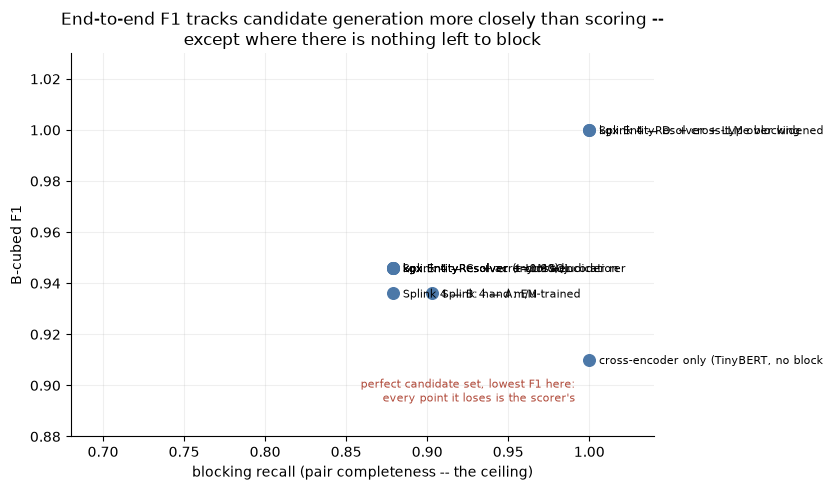

In [36]:
import matplotlib.pyplot as plt

plot_df = board.dropna(subset=["blocking recall"]).copy()
fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.scatter(plot_df["blocking recall"], plot_df["B3 F1"], s=70, color="#4C78A8", zorder=3)
for _, r in plot_df.iterrows():
    ax.annotate(r["approach"][:38], (r["blocking recall"], r["B3 F1"]),
                textcoords="offset points", xytext=(7, -3), fontsize=8)
ax.annotate("perfect candidate set, lowest F1 here:\nevery point it loses is the scorer's",
            (1.0, float(board.loc[board.approach.str.startswith("cross-encoder only"),
                                  "B3 F1"].iloc[0])),
            textcoords="offset points", xytext=(-10, -30),
            fontsize=8, color="#B04A3A", ha="right", zorder=4)
ax.set_xlabel("blocking recall (pair completeness -- the ceiling)")
ax.set_ylabel("B-cubed F1")
ax.set_title("End-to-end F1 tracks candidate generation more closely than scoring --\n"
             "except where there is nothing left to block")
ax.grid(alpha=0.2); ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0.68, 1.04); ax.set_ylim(min(plot_df["B3 F1"]) - 0.03, 1.03)
plt.tight_layout(); plt.show()

## 8. What the numbers say

**The repo's own pipeline is not the best system here, and its scorer is not the reason.**
`kgx.EntityResolver` gets B-cubed F1 0.946 at precision 1.000 — it never merges two entities gold says are
different. Every point it loses is recall, and every one of those points is a pair it never scored. Two of
the alternatives reach 1.000 and both get there by widening candidate generation — though Splink's config D
also needed a softer type penalty before the newly blocked pairs would merge (§3).

**Splink's machinery earns its place; Splink's statistics do not.** DuckDB blocking, comparison-vector
bookkeeping and connected-components clustering in about forty lines of configuration over a library you
install rather than maintain, and under a tenth of a second, against 866 lines in `src/kgx/resolve.py` you
own outright and that run roughly twice as slow — 0.15 s to config D's 0.07 s, one wall-clock run each with
setup excluded on both sides — is a real win. But expectation–maximisation
contributed nothing — hand-set m/u tied the EM-trained model exactly — because Fellegi–Sunter assumes
several conditionally independent fields and this table has one informative column. Splink says so itself at
predict time: *"Comparison: 'type': m values not fully trained"*. Use `SettingsCreator` with
`CustomComparison`, skip all three `training.*` calls, and treat `match_probability` as an unnormalised
rank. The best threshold here is 0.1; at the conventional 0.9 line every configuration collapses to
F1 0.34–0.84.

**dedupe finds the right blocking predicate, and how reliably it finds it is set by the label budget.** With oracle
labels over all thirteen entities it learned `sortedAcronym(name)` unprompted — the thing Splink needed ten
lines of hand-written DuckDB for — and scored 0.968, the best result in this notebook from a model that was
actually trained. That is train-on-test. The rules-only run learned a TF-IDF n-gram canopy conjoined with
`wholeFieldPredicate(type)` instead, and scored 0.835 — below the baseline. Fits replay exactly at a fixed
seed, so all the movement is in the label sample: five seeds at 40/60 labels span F1 0.922 to 0.968, sd
0.021, with the 0.968 headline at the top of that range and not its middle; halve the budget to 25/25 and
the same code spans 0.438 to 0.945, sd 0.215, the worst seed picking `wholeFieldPredicate(type)` and fusing
each extractor type into a single cluster. A dedupe number in a comparison table means nothing without the
label budget and the seed spread beside it.

**The review band is the wrong place to spend an adjudicator, and that is a finding about this repo.**
Both tiers — a 125M-parameter cross-encoder and Claude Haiku — were pointed at the 0.78–0.90 band that
`Resolution.review_band()` exists to produce. Both were essentially perfect on it: the cross-encoder promoted
all 34 labelled pairs correctly, and the LLM agreed with gold on all 34 while saying *different* on three
unlabelled ones — twice on adjusted against unadjusted `operating margin`, once on `gross margin` against
`non-GAAP gross margin` — defensible calls that no gold label settles either way. Neither moved B-cubed by a
thousandth: the 34 labelled pairs were already merged transitively by some other edge, and the unlabelled
promotions that *do* change the clustering — 109 clusters to 105 for the cross-encoder, 107 for the LLM —
are invisible to a 36%-labelled metric. A review queue built on that band would give a human real work and
produce no measurable improvement.

**Cross-encoders have no notion of an abbreviation.** They score `HLCN` against `Halcyon` at 0.13 on a 0–1
STS head and −11.3 on a reranker whose range over this data is −11.6 to +10.8 — not merely wrong, maximally
wrong. The 0.99 AUC over all 22,791 pairs is earned on the twenty-two thousand obvious negatives. What they
do have is throughput: over eighteen thousand pairs per second on CPU for the two-layer TinyBERT, enough
to skip blocking entirely. That is a real capability aimed at the wrong failure — the no-blocking candidate
set reaches pair completeness 0.894 against the hand-rolled blocker's 0.879 at the same 1,462-pair budget,
and clustering on those scores alone tops out at 0.910.

**One sentence of domain policy was worth more than everything else in the LLM tier.** Over a type-agnostic
candidate set of 343 distinct questions, three independent passes returned identical verdicts, recovered all
41 cross-type gold pairs, and took B-cubed from 0.946 to 1.000 — for about six cents a pass, $0.19 for all
three, roughly two hundredths of a cent per adjudicated question. Remove the sentence telling the model that a
ticker and its company are the same entity, re-ask all 343 questions, and the answer degrades in both
directions: two true merges are lost — `Torrent Microsystems` and `Vantage Energy Partners`, each an
identical surface string typed once as a company and once as a security — and three false ones appear, `NWL`
fused with its automotive segment, with the Cascade Freight transaction, and with the Cascade brand. B-cubed
charges for the first pair and not the second: it falls to 0.979 for the two merges that were dropped, while
all three of the merges that were invented are invisible to a 36%-labelled evaluation set.

### Which one is right for you

| situation | use |
|---|---|
| clean records, several independent fields, millions of rows | **Splink** — the shape Fellegi–Sunter was built for, where none of the caveats above apply |
| one name column, no labels, more rows than you want to score | **Splink with hand-set m/u** — keep the DuckDB machinery, skip `training.*`, and sweep the threshold against whatever labels you can assemble |
| you can label a few hundred pairs and want blocking discovered for you | **dedupe** — then pin the trained model with `write_settings()` and never retrain in place, because a different label sample gives a different predicate, and keep `uncertain_pairs()` out of any run you need to replay, since its generator is unseeded |
| identity is not a string property — tickers, abbreviations, product codes, part numbers | **an LLM over a deliberately widened candidate set**, at roughly $0.0002 per question, and write the identity policy into the prompt |
| you need to reject a merge, not just find one | **an LLM again** — the only tier here that ever said *different*: 337 of 343 widened questions and 3 of 39 band pairs, and no rejection cost a gold pair (recall 1.000) |
| every merge must be auditable | **the hand-rolled pipeline** — `ScoredPair.reason` names the evidence, which no probability and no logit does |
| you are about to build a review UI | **measure the band first.** Here it held 39 pairs, no labelled disagreement, and nothing in it a gold label could score |

### Where to take it

**Print blocking recall next to F1, always.** The spread of end-to-end F1 in the scoreboard tracks
candidate generation much more closely than it tracks scoring quality, and nearly every configuration here
reached precision 1.000 on the labelled subset. A comparison that reports only F1 sends you to tune the half
that was already right.

**Label more than 36% of the mentions.** Splink config D's third-largest cluster fuses eight distinct
financial-metric surfaces and the metric still reports 1.000. The neutral-prompt LLM invents three merges
that cost it precisely nothing, because every mention in them is unlabelled; its score moves only for the
two true merges it also dropped. The over-merge audit in §3 is the only thing between these scores and a
system that quietly merges everything nobody labelled. Pooled adjudication over the union of what all five
approaches produced is the right fix, and is not done here.

**Splink config D is hand-tuned against the evaluation set.** Its blocking rules and its softened type
penalty were written after reading §1's list of missing pairs. Treat its 1.000 as evidence that the ceiling
is reachable, not as a held-out result. The LLM path is cleaner on this point — the candidate rule is a
regex over uppercase tokens and the model never sees a label — but its prompt was written knowing the answer
too. A second corpus settles both.

**Fix the extractor instead.** Every hard case in this notebook exists because GLiNER typed `HLCN` as
`security` and `Halcyon` as `company`. Type consistency is an extraction problem; enforcing one canonical
type per surface form, or resolving before typing, deletes the entire gap that four of these five approaches
spend their effort on.